## 02-seq2seq: Experiment 노트북

### 목표
- LSTM 및 Attention으로 구성한 Seq-to-Seq 모델을 작은 batch에서 over-fitting
- Synthetic Reverse Task에서 학습 확인
- Attention을 이용한 Seq-to-seq에서 Attention Map 시각화
- 번역 태스크에서 Attention 유무에 따른 성능 비교

### 1. Import 및 설정

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [72]:
import re
import math
import copy
import random
from functools import partial
from typing import Tuple, Dict, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import TensorDataset, DataLoader
from datasets import load_dataset
from sacrebleu.metrics import BLEU

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from model import Seq2Seq, AttentionSeq2Seq
from data import synthetic_reverse_dataset, build_vocab, encode_text, decode_text, translate_collate_fn

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.random.manual_seed(seed)

set_seed()

### 2. 작은 Batch에서 LSTM Seq2seq 모델 Overfitting 확인

In [4]:
batch_size = 16
min_seq, max_seq = 3, 6
embedding_size = 32
hidden_size = 64
vocab_size = 13

PAD_TOKEN = 0
BOS_TOKEN = 1
EOS_TOKEN = 2

source, target_input, target_output, valid_mask = \
    synthetic_reverse_dataset(batch_size=batch_size, min_seq=min_seq, max_seq=max_seq)

model = Seq2Seq(source_vocab_size=vocab_size, target_vocab_size=vocab_size, embedding_size=embedding_size, hidden_size=hidden_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
eval_mask = target_output != PAD_TOKEN

Step 0: loss=2.59, acc=0.05
Step 10: loss=0.96, acc=0.73
Step 20: loss=0.13, acc=1.00
Step 30: loss=0.02, acc=1.00
Step 40: loss=0.01, acc=1.00
Step 50: loss=0.00, acc=1.00
Step 60: loss=0.00, acc=1.00
Step 70: loss=0.00, acc=1.00
Step 80: loss=0.00, acc=1.00
Step 90: loss=0.00, acc=1.00


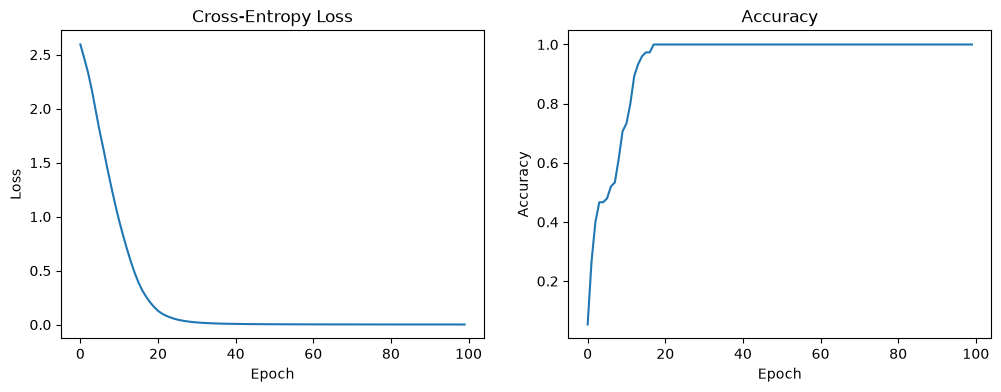

In [5]:
loss_history, acc_history = [], []
model.train()
for i in range(100):
    optimizer.zero_grad()
    logits = model(source, target_input, valid_mask)
    loss = loss_fn(logits.reshape(-1, vocab_size), target_output.reshape(-1))
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    correct = (logits.argmax(dim=-1) == target_output) & eval_mask
    acc_history.append((torch.sum(correct) / torch.sum(eval_mask)).item())

    if i % 10 == 0:
        print(f"Step {i}: loss={loss.item():.2f}, acc={(torch.sum(correct) / torch.sum(eval_mask)):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history)
axes[0].set(title="Cross-Entropy Loss", xlabel="Epoch", ylabel='Loss')
axes[1].plot(acc_history)
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
plt.show()

#### 2-1. Greedy Decoding 및 Accuracy 평가 지표

In [6]:
# 학습한 모델을 이용해, Input Sequence에 대해 Decoder가 생성한 Token IDs 반환
model.eval()

with torch.no_grad():
    pred_ids = model.greedy_decode(
        source=source,
        valid_mask=valid_mask,
        max_new_tokens=target_output.shape[1]
    )

if pred_ids.shape[1] != target_output.shape[1]:
    pred_ids = F.pad(pred_ids, (0, target_output.shape[1]-pred_ids.shape[1]), value=PAD_TOKEN)

for pred, true in zip(pred_ids, target_output):
    print(f"Predicted: {pred}, True: {true}")

Predicted: tensor([ 9, 10,  5,  2,  0,  0,  0]), True: tensor([ 9, 10,  5,  2,  0,  0,  0])
Predicted: tensor([8, 9, 7, 2, 0, 0, 0]), True: tensor([8, 9, 7, 2, 0, 0, 0])
Predicted: tensor([11,  6,  3,  7,  3,  2,  0]), True: tensor([11,  6,  3,  7,  3,  2,  0])
Predicted: tensor([4, 7, 3, 7, 2, 0, 0]), True: tensor([4, 7, 3, 7, 2, 0, 0])
Predicted: tensor([10,  8,  8,  5,  2,  0,  0]), True: tensor([10,  8,  8,  5,  2,  0,  0])
Predicted: tensor([ 6,  9, 12,  9,  2,  0,  0]), True: tensor([ 6,  9, 12,  9,  2,  0,  0])
Predicted: tensor([ 6, 12,  4,  2,  0,  0,  0]), True: tensor([ 6, 12,  4,  2,  0,  0,  0])
Predicted: tensor([10, 12,  4,  2,  0,  0,  0]), True: tensor([10, 12,  4,  2,  0,  0,  0])
Predicted: tensor([ 6, 12,  8,  3,  5, 12,  2]), True: tensor([ 6, 12,  8,  3,  5, 12,  2])
Predicted: tensor([ 9, 12,  7,  2,  0,  0,  0]), True: tensor([ 9, 12,  7,  2,  0,  0,  0])
Predicted: tensor([9, 3, 5, 2, 0, 0, 0]), True: tensor([9, 3, 5, 2, 0, 0, 0])
Predicted: tensor([12, 10,  5,

In [7]:
# 각 sequence 별 accuracy 확인
accuracy = (pred_ids == target_output)
accuracy = torch.all(accuracy, dim=1)
baseline_sequence_accuracy = accuracy.sum() / accuracy.size(0)
print("Accuracy:", baseline_sequence_accuracy.item())

Accuracy: 1.0


### 3. 작은 Batch에서 Attention Seq2seq 모델 Overfitting 확인

Step 0: loss=2.54, acc=0.17
Step 10: loss=0.72, acc=0.89
Step 20: loss=0.08, acc=1.00
Step 30: loss=0.01, acc=1.00
Step 40: loss=0.01, acc=1.00
Step 50: loss=0.00, acc=1.00
Step 60: loss=0.00, acc=1.00
Step 70: loss=0.00, acc=1.00
Step 80: loss=0.00, acc=1.00
Step 90: loss=0.00, acc=1.00


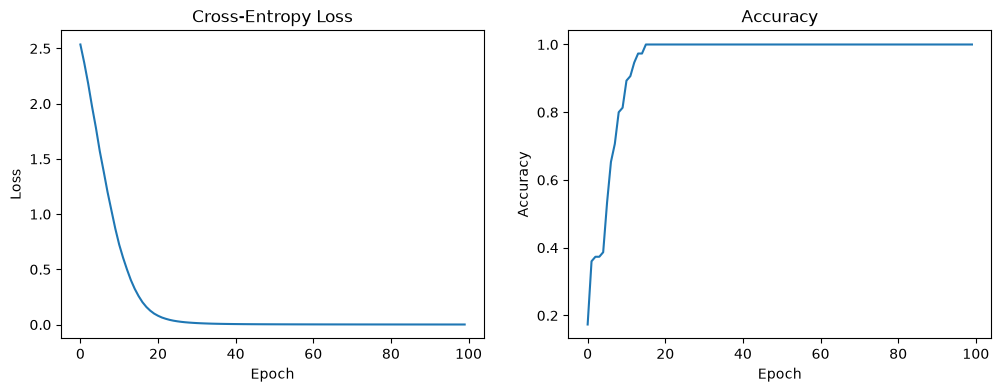

In [8]:
attention_model = AttentionSeq2Seq(
    source_vocab_size=vocab_size, 
    target_vocab_size=vocab_size,
    embedding_size=embedding_size, 
    hidden_size=hidden_size, 
    attention_size=hidden_size
)
attention_optimizer = torch.optim.Adam(attention_model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)
eval_mask = target_output != PAD_TOKEN

attention_model.train()
attention_loss_history, attention_acc_history = [], []
for i in range(100):
    attention_optimizer.zero_grad()
    logits, attention_weights = attention_model(source, target_input, valid_mask)
    loss = loss_fn(logits.reshape(-1, vocab_size), target_output.reshape(-1))
    loss.backward()
    attention_optimizer.step()

    attention_loss_history.append(loss.item())
    correct = (logits.argmax(dim=-1) == target_output) & eval_mask
    attention_acc_history.append((torch.sum(correct) / torch.sum(eval_mask)).item())

    if i % 10 == 0:
        print(f"Step {i}: loss={loss.item():.2f}, acc={(torch.sum(correct) / torch.sum(eval_mask)):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(attention_loss_history)
axes[0].set(title="Cross-Entropy Loss", xlabel="Epoch", ylabel='Loss')
axes[1].plot(attention_acc_history)
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
plt.show()

#### 3-1. Greedy Decoding 및 Accuracy 평가 지표

In [9]:
attention_model.eval()
with torch.no_grad():
    pred_ids, attention_weights = attention_model.greedy_decode(
        source=source,
        valid_mask=valid_mask,
        max_new_tokens=target_output.shape[1]
    )

if pred_ids.shape[1] != target_output.shape[1]:
    pred_ids = F.pad(pred_ids, (0, target_output.shape[1]-pred_ids.shape[1]), value=PAD_TOKEN)

for pred, true in zip(pred_ids, target_output):
    print(f"Predicted: {pred}, True: {true}")

accuracy = (pred_ids == target_output)
accuracy = torch.all(accuracy, dim=1)
attention_sequence_accuracy = accuracy.sum() / accuracy.size(0)
print("=" * 50)
print("Accuracy:", attention_sequence_accuracy.item())

Predicted: tensor([ 9, 10,  5,  2,  0,  0,  0]), True: tensor([ 9, 10,  5,  2,  0,  0,  0])
Predicted: tensor([8, 9, 7, 2, 0, 0, 0]), True: tensor([8, 9, 7, 2, 0, 0, 0])
Predicted: tensor([11,  6,  3,  7,  3,  2,  0]), True: tensor([11,  6,  3,  7,  3,  2,  0])
Predicted: tensor([4, 7, 3, 7, 2, 0, 0]), True: tensor([4, 7, 3, 7, 2, 0, 0])
Predicted: tensor([10,  8,  8,  5,  2,  0,  0]), True: tensor([10,  8,  8,  5,  2,  0,  0])
Predicted: tensor([ 6,  9, 12,  9,  2,  0,  0]), True: tensor([ 6,  9, 12,  9,  2,  0,  0])
Predicted: tensor([ 6, 12,  4,  2,  0,  0,  0]), True: tensor([ 6, 12,  4,  2,  0,  0,  0])
Predicted: tensor([10, 12,  4,  2,  0,  0,  0]), True: tensor([10, 12,  4,  2,  0,  0,  0])
Predicted: tensor([ 6, 12,  8,  3,  5, 12,  2]), True: tensor([ 6, 12,  8,  3,  5, 12,  2])
Predicted: tensor([ 9, 12,  7,  2,  0,  0,  0]), True: tensor([ 9, 12,  7,  2,  0,  0,  0])
Predicted: tensor([9, 3, 5, 2, 0, 0, 0]), True: tensor([9, 3, 5, 2, 0, 0, 0])
Predicted: tensor([12, 10,  5,

### 4. Attention 유무에 따른 성능 비교
- 앞서 사용한 `synthetic_reverse_dataset`을 이용해서 여러 길이의 데이터셋을 생성
- LSTM만을 이용한 Seq2Seq 모델과 Attention을 이용한 Seq2Seq 모델을 이용해서 학습
- 두 모델의 입력 길이에 따른 성능 비교

In [10]:
set_seed(42)

vocab_size = 13
batch_size = 64
train_data_len = 1024
valid_data_len = 128
min_seq, max_seq = 5, 50

# Train Dataset 생성
train_source, train_target_input, train_target_output, train_valid_mask = \
    synthetic_reverse_dataset(batch_size=train_data_len, min_seq=min_seq, max_seq=max_seq)
train_dataset = TensorDataset(
    train_source, train_target_input, train_target_output, train_valid_mask
)

# Short Validation Dataset 생성
short_valid_source, short_valid_target_input, short_valid_target_output, short_valid_mask = \
    synthetic_reverse_dataset(batch_size=valid_data_len, min_seq=min_seq, max_seq=10)
short_valid_dataset = TensorDataset(
    short_valid_source, short_valid_target_input, short_valid_target_output, short_valid_mask
)

# Long Validataion Dataset 생성
long_valid_source, long_valid_target_input, long_valid_target_output, long_valid_mask = \
    synthetic_reverse_dataset(batch_size=valid_data_len, min_seq=40, max_seq=max_seq)
long_valid_dataset = TensorDataset(
    long_valid_source, long_valid_target_input, long_valid_target_output, long_valid_mask
)

# 각 DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
short_valid_loader = DataLoader(short_valid_dataset, batch_size=batch_size, shuffle=False)
long_valid_loader = DataLoader(long_valid_dataset, batch_size=batch_size, shuffle=False)

print(f"Train Dataset Length Range: {train_valid_mask.sum(dim=1).min()}~{train_valid_mask.sum(dim=1).max()}")
print(f"Short Valid Dataset Length Range: {short_valid_mask.sum(dim=1).min()}~{short_valid_mask.sum(dim=1).max()}")
print(f"Long Valid Dataset Length Range: {long_valid_mask.sum(dim=1).min()}~{long_valid_mask.sum(dim=1).max()}")

Train Dataset Length Range: 5~50
Short Valid Dataset Length Range: 5~10
Long Valid Dataset Length Range: 40~50


In [11]:
embedding_size = 32
hidden_size = 64
lr = 0.01
num_epochs = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'

set_seed(42)
baseline_model = Seq2Seq(
    source_vocab_size=vocab_size,
    target_vocab_size=vocab_size,
    embedding_size=embedding_size,
    hidden_size=hidden_size
).to(device)

set_seed(42)
attention_model = AttentionSeq2Seq(
    source_vocab_size=vocab_size,
    target_vocab_size=vocab_size,
    embedding_size=embedding_size,
    hidden_size=hidden_size,
    attention_size=hidden_size
).to(device)

baseline_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=lr)
attention_optimizer = torch.optim.Adam(attention_model.parameters(), lr=lr)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

#### 4-1. Train 함수 작성

In [12]:
# Week 1의 Train Step 흐름을 이용
def train_step(
    model: Seq2Seq | AttentionSeq2Seq,
    source: Tensor,
    target_input: Tensor,
    target_output: Tensor,
    valid_mask: Tensor,
    loss_fn,
    optimizer,
    device
):
    model.train()
    source, target_input, target_output, valid_mask = \
        source.to(device), target_input.to(device), target_output.to(device), valid_mask.to(device)

    # 1. optimizer의 gradient 초기화
    optimizer.zero_grad()
    # 2. model forward
    logits = model(source, target_input, valid_mask)
    if isinstance(logits, tuple):
        logits = logits[0]
    # 3. loss 구하기
    loss = loss_fn(logits.reshape(-1, logits.size(-1)), target_output.reshape(-1))
    # 4. loss backward
    loss.backward()
    # 5. optimizer step
    optimizer.step()

    return loss.item()


def train(
    model, train_loader, loss_fn, optimizer, num_epochs, device
):
    train_loss = []
    for epoch in range(num_epochs):
        loss_sum, token_count = 0, 0
        for source, target_input, target_output, valid_mask in train_loader:
            batch_loss = train_step(
                model, source, target_input, target_output, valid_mask, loss_fn, optimizer, device
            )
            batch_token_count = torch.sum(target_output != PAD_TOKEN).item()

            loss_sum += batch_loss * batch_token_count
            token_count += batch_token_count
        epoch_loss = loss_sum / token_count
        train_loss.append(epoch_loss)
        print(f"Epoch {epoch+1}: Loss={epoch_loss:.2f}")
    return train_loss

In [13]:
print("=" * 50)
print("Train Baseline LSTM Seq2Seq Model...")
baseline_train_loss = train(baseline_model, train_loader, loss_fn, baseline_optimizer, num_epochs, device)

print("=" * 50)
print("Train Attention-based Seq2Seq Model...")
attention_train_loss = train(attention_model, train_loader, loss_fn, attention_optimizer, num_epochs, device)

Train Baseline LSTM Seq2Seq Model...
Epoch 1: Loss=2.39
Epoch 2: Loss=2.23
Epoch 3: Loss=2.08
Epoch 4: Loss=1.94
Epoch 5: Loss=1.82
Epoch 6: Loss=1.73
Epoch 7: Loss=1.65
Epoch 8: Loss=1.58
Epoch 9: Loss=1.52
Epoch 10: Loss=1.47
Epoch 11: Loss=1.45
Epoch 12: Loss=1.40
Epoch 13: Loss=1.36
Epoch 14: Loss=1.32
Epoch 15: Loss=1.30
Epoch 16: Loss=1.29
Epoch 17: Loss=1.25
Epoch 18: Loss=1.23
Epoch 19: Loss=1.21
Epoch 20: Loss=1.19
Train Attention-based Seq2Seq Model...
Epoch 1: Loss=2.38
Epoch 2: Loss=2.22
Epoch 3: Loss=2.05
Epoch 4: Loss=1.90
Epoch 5: Loss=1.71
Epoch 6: Loss=1.50
Epoch 7: Loss=1.31
Epoch 8: Loss=1.17
Epoch 9: Loss=0.99
Epoch 10: Loss=0.79
Epoch 11: Loss=0.75
Epoch 12: Loss=0.73
Epoch 13: Loss=0.70
Epoch 14: Loss=0.62
Epoch 15: Loss=0.47
Epoch 16: Loss=0.51
Epoch 17: Loss=0.57
Epoch 18: Loss=0.77
Epoch 19: Loss=0.63
Epoch 20: Loss=0.77


#### 4-2. Evaluate 함수 구현

In [14]:
def evaluate(model, dataloader, device):
    model.eval()
    token_corr, seq_corr = 0, 0
    all_token, all_seq = 0, 0
    with torch.no_grad():
        for source, target_input, target_output, valid_mask in dataloader:
            source, target_input, target_output, valid_mask = \
                source.to(device), target_input.to(device), target_output.to(device), valid_mask.to(device)

            token_ids = model.greedy_decode(source, valid_mask, max_new_tokens=target_output.size(1))
            if isinstance(token_ids, tuple):
                token_ids = token_ids[0]

            if token_ids.shape[1] != target_output.shape[1]:
                pad_length = target_output.shape[1] - token_ids.shape[1]
                token_ids = F.pad(token_ids, (0, pad_length), value=PAD_TOKEN)

            target_mask = target_output != PAD_TOKEN
            token_corr += torch.sum((token_ids == target_output) & target_mask)
            seq_corr += torch.all(token_ids == target_output, dim=1).sum()
            all_token += torch.sum(target_mask)
            all_seq += target_output.size(0)
    return token_corr / all_token, seq_corr / all_seq

In [15]:
print("=" * 50)
print("Evaluate Baseline LSTM Seq2Seq Model on Short Validation...")
baseline_short_acc = evaluate(baseline_model, short_valid_loader, device)
print(f"Token Acc: {baseline_short_acc[0]:.2f}, Sequence Acc: {baseline_short_acc[1]:.2f}")

print("=" * 50)
print("Evaluate Baseline LSTM Seq2Seq Model on Long Validation...")
baseline_long_acc = evaluate(baseline_model, long_valid_loader, device)
print(f"Token Acc: {baseline_long_acc[0]:.2f}, Sequence Acc: {baseline_long_acc[1]:.2f}")

print("=" * 50)
print("Evaluate Attention-based Seq2Seq Model on Short Validation...")
attention_short_acc = evaluate(attention_model, short_valid_loader, device)
print(f"Token Acc: {attention_short_acc[0]:.2f}, Sequence Acc: {attention_short_acc[1]:.2f}")

print("=" * 50)
print("Evaluate Attention-based Seq2Seq Model on Long Validation...")
attention_long_acc = evaluate(attention_model, long_valid_loader, device)
print(f"Token Acc: {attention_long_acc[0]:.2f}, Sequence Acc: {attention_long_acc[1]:.2f}")

Evaluate Baseline LSTM Seq2Seq Model on Short Validation...
Token Acc: 0.84, Sequence Acc: 0.52
Evaluate Baseline LSTM Seq2Seq Model on Long Validation...
Token Acc: 0.25, Sequence Acc: 0.00
Evaluate Attention-based Seq2Seq Model on Short Validation...
Token Acc: 0.81, Sequence Acc: 0.53
Evaluate Attention-based Seq2Seq Model on Long Validation...
Token Acc: 0.31, Sequence Acc: 0.00


#### 4-3. 추가 평가

In [16]:
# mid Validation Dataset 생성
mid_valid_source, mid_valid_target_input, mid_valid_target_output, mid_valid_mask = \
    synthetic_reverse_dataset(batch_size=valid_data_len, min_seq=15, max_seq=20)
mid_valid_dataset = TensorDataset(
    mid_valid_source, mid_valid_target_input, mid_valid_target_output, mid_valid_mask
)

# midlong Validation Dataset 생성
midlong_valid_source, midlong_valid_target_input, midlong_valid_target_output, midlong_valid_mask = \
    synthetic_reverse_dataset(batch_size=valid_data_len, min_seq=25, max_seq=30)
midlong_valid_dataset = TensorDataset(
    midlong_valid_source, midlong_valid_target_input, midlong_valid_target_output, midlong_valid_mask
)

mid_valid_loader = DataLoader(mid_valid_dataset, batch_size=batch_size, shuffle=False)
midlong_valid_loader = DataLoader(midlong_valid_dataset, batch_size=batch_size, shuffle=False)

In [17]:
print("=" * 50)
print("Evaluate Baseline LSTM Seq2Seq Model on Mid Validation...")
baseline_mid_acc = evaluate(baseline_model, mid_valid_loader, device)
print(f"Token Acc: {baseline_mid_acc[0]:.2f}, Sequence Acc: {baseline_mid_acc[1]:.2f}")

print("=" * 50)
print("Evaluate Baseline LSTM Seq2Seq Model on MidLong Validation...")
baseline_midlong_acc = evaluate(baseline_model, midlong_valid_loader, device)
print(f"Token Acc: {baseline_midlong_acc[0]:.2f}, Sequence Acc: {baseline_midlong_acc[1]:.2f}")

print("=" * 50)
print("Evaluate Attention-based Seq2Seq Model on Mid Validation...")
attention_mid_acc = evaluate(attention_model, mid_valid_loader, device)
print(f"Token Acc: {attention_mid_acc[0]:.2f}, Sequence Acc: {attention_mid_acc[1]:.2f}")

print("=" * 50)
print("Evaluate Attention-based Seq2Seq Model on MidLong Validation...")
attention_midlong_acc = evaluate(attention_model, midlong_valid_loader, device)
print(f"Token Acc: {attention_midlong_acc[0]:.2f}, Sequence Acc: {attention_midlong_acc[1]:.2f}")

Evaluate Baseline LSTM Seq2Seq Model on Mid Validation...
Token Acc: 0.48, Sequence Acc: 0.00
Evaluate Baseline LSTM Seq2Seq Model on MidLong Validation...
Token Acc: 0.34, Sequence Acc: 0.00
Evaluate Attention-based Seq2Seq Model on Mid Validation...
Token Acc: 0.64, Sequence Acc: 0.11
Evaluate Attention-based Seq2Seq Model on MidLong Validation...
Token Acc: 0.46, Sequence Acc: 0.00


#### 4-4. 길이별 성능 비교

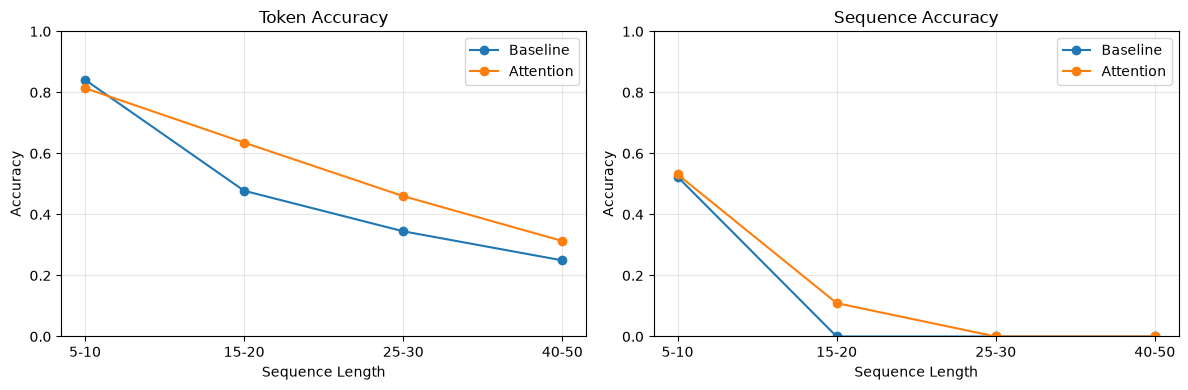

In [18]:
length_ranges = ["5-10", "15-20", "25-30", "40-50"]
baseline_accs = [baseline_short_acc, baseline_mid_acc, baseline_midlong_acc, baseline_long_acc]
attention_accs = [attention_short_acc, attention_mid_acc, attention_midlong_acc, attention_long_acc]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name, accs in [("Baseline", baseline_accs), ("Attention", attention_accs)]:
    axes[0].plot(length_ranges, [acc[0].to('cpu') for acc in accs], marker="o", label=model_name)
    axes[1].plot(length_ranges, [acc[1].to('cpu') for acc in accs], marker="o", label=model_name)

for ax, title in zip(axes, ["Token Accuracy", "Sequence Accuracy"]):
    ax.set(title=title, xlabel="Sequence Length", ylabel="Accuracy", ylim=(0, 1))
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

#### 4-5. Attention Map 시각화

In [19]:
sample_idx = 0
source, _, target_output, valid_mask = mid_valid_dataset[sample_idx]

source_length = valid_mask.sum().item()

# PAD 영역 제거 후 batch 차원 추가
source = source[:source_length].unsqueeze(0).to(device)
valid_mask = valid_mask[:source_length].unsqueeze(0).to(device)

attention_model.eval()
with torch.no_grad():
    pred_ids, attention_weights = attention_model.greedy_decode(
        source=source,
        valid_mask=valid_mask,
        max_new_tokens=source_length + 1,
    )

print("source:", source.shape)
print("prediction:", pred_ids.shape)
print("attention:", attention_weights.shape)

source: torch.Size([1, 20])
prediction: torch.Size([1, 21])
attention: torch.Size([1, 21, 20])


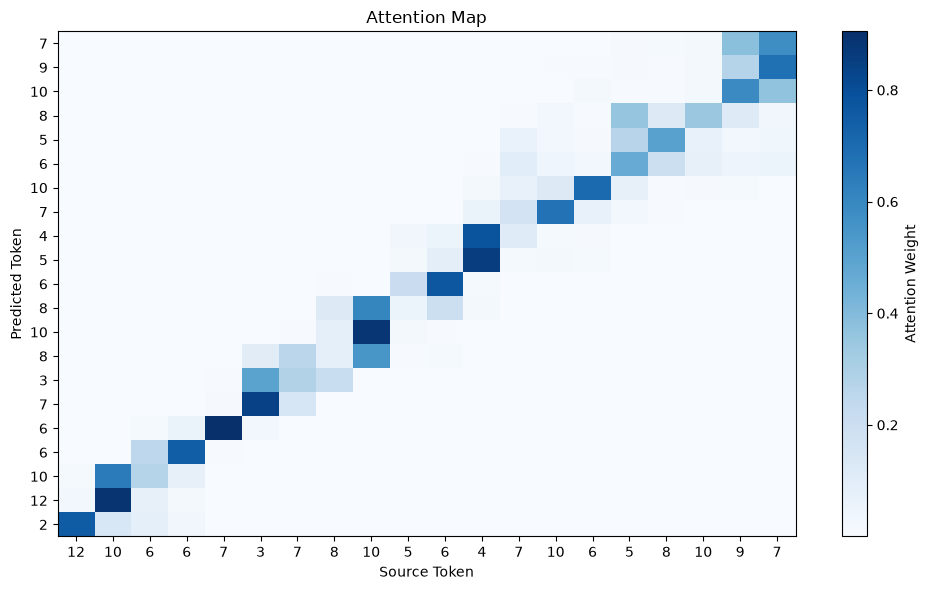

In [20]:
attention_map = attention_weights[0].cpu()
source_ids = source[0].cpu().tolist()
predicted_ids = pred_ids[0].cpu().tolist()

fig, ax = plt.subplots(figsize=(10, 6))

image = ax.imshow(
    attention_map.numpy(),
    aspect="auto",
    cmap="Blues",
)

ax.set_xticks(range(len(source_ids)), labels=source_ids)
ax.set_yticks(range(len(predicted_ids)), labels=predicted_ids)

ax.set_xlabel("Source Token")
ax.set_ylabel("Predicted Token")
ax.set_title("Attention Map")

fig.colorbar(image, ax=ax, label="Attention Weight")
plt.tight_layout()
plt.show()

# 특정 Predicted Token을 예측했을 때, 참고한 Source Token의 Attention 분포

### 5. `Multi30k` 데이터셋으로 기계번역 태스크 진행하기

#### 5-1. Dataset 및 DataLoader 구성하기

In [21]:
dataset = load_dataset("bentrevett/multi30k")

print(dataset)
print(dataset['train'][0])

README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})
{'en': 'Two young, White males are outside near many bushes.', 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}


In [22]:
# 각 de/en 언어별로 vocabulary 생성
de_vocab = build_vocab(dataset['train']['de'], min_freq=2)
en_vocab = build_vocab(dataset['train']['en'], min_freq=2)

assert de_vocab[:4] == ["<pad>", "<bos>", "<eos>", "<unk>"]
assert en_vocab[:4] == ["<pad>", "<bos>", "<eos>", "<unk>"]

print("German vocab:", len(de_vocab), de_vocab[:10])
print("English vocab:", len(en_vocab), en_vocab[:10])

German vocab: 7864 ['<pad>', '<bos>', '<eos>', '<unk>', '.', 'ein', 'einem', 'in', 'eine', ',']
English vocab: 5937 ['<pad>', '<bos>', '<eos>', '<unk>', 'a', '.', 'in', 'the', 'on', 'man']


In [23]:
# 각 언어별 token_to_id 생성
de_token_to_id = {
    token: token_id
    for token_id, token in enumerate(de_vocab)
}
en_token_to_id = {
    token: token_id
    for token_id, token in enumerate(en_vocab)
}

sample = dataset["train"][0]

source_ids = encode_text(sample["de"], de_token_to_id)
target_ids = encode_text(sample["en"], en_token_to_id)

assert len(source_ids) > 0
assert len(target_ids) > 0
assert max(source_ids) < len(de_vocab)
assert max(target_ids) < len(en_vocab)

print(f"Source IDs: {source_ids}")
print(f"Target IDs: {target_ids}")

Source IDs: [18, 26, 214, 30, 84, 20, 88, 7, 15, 114, 7655, 3207, 4]
Target IDs: [16, 24, 14, 25, 774, 17, 56, 79, 198, 1307, 5]


In [24]:
# DataLoader 만들기

multi30k_collate_fn = partial(
    translate_collate_fn,
    source_token_to_id=de_token_to_id,
    target_token_to_id=en_token_to_id,
) # DataLoader는 `collate_fn(batch)`만 호출하므로 나머지 인자를 `partial`로 고정

train_loader = DataLoader(
    dataset=dataset['train'],
    batch_size=4,
    shuffle=False,
    collate_fn=multi30k_collate_fn
)

batch_source, batch_target_input, batch_target_output, batch_valid_mask = \
    next(iter(train_loader))

assert batch_source.shape == batch_valid_mask.shape
assert batch_target_input.shape == batch_target_output.shape
assert batch_source.shape[0] == 4
assert torch.all(
    batch_target_input[:, 0] == en_token_to_id["<bos>"]
)

print("source:", batch_source.shape)
print("target_input:", batch_target_input.shape)
print("target_output:", batch_target_output.shape)
print("valid_mask:", batch_valid_mask.shape)

source_lengths = batch_valid_mask.sum(dim=1)
batch_indices = torch.arange(batch_source.size(0))

source_last_tokens = batch_source[
    batch_indices,
    source_lengths - 1,
]

assert torch.all(
    source_last_tokens == de_token_to_id["<eos>"]
)

source: torch.Size([4, 16])
target_input: torch.Size([4, 16])
target_output: torch.Size([4, 16])
valid_mask: torch.Size([4, 16])


In [25]:
valid_loader = DataLoader(
    dataset=dataset['validation'],
    batch_size=4,
    shuffle=False,
    collate_fn=multi30k_collate_fn
)
test_loader = DataLoader(
    dataset=dataset['test'],
    batch_size=4,
    shuffle=False,
    collate_fn=multi30k_collate_fn
)

#### 5-2. 실제 데이터가 작동하는지 검증

In [26]:
emb_size = 32
hidden_size = 64

baseline = Seq2Seq(
    source_vocab_size=len(de_vocab),
    target_vocab_size=len(en_vocab),
    embedding_size=emb_size,
    hidden_size=hidden_size
)
attention = AttentionSeq2Seq(
    source_vocab_size=len(de_vocab),
    target_vocab_size=len(en_vocab),
    embedding_size=emb_size,
    hidden_size=hidden_size,
    attention_size=hidden_size
)

with torch.no_grad():
    baseline_logits = baseline(
        source=batch_source,
        target_input=batch_target_input,
        valid_mask=batch_valid_mask,
    )
    attention_logits, attention_weights = attention(
        source=batch_source,
        target_input=batch_target_input,
        valid_mask=batch_valid_mask,
    )

expected_logits_shape = (
    batch_source.size(0),
    batch_target_input.size(1),
    len(en_vocab),
)

assert baseline_logits.shape == expected_logits_shape
assert attention_logits.shape == expected_logits_shape
assert attention_weights.shape == (
    batch_source.size(0),
    batch_target_input.size(1),
    batch_source.size(1),
)
assert torch.isfinite(baseline_logits).all()
assert torch.isfinite(attention_logits).all()

print("baseline:", baseline_logits.shape)
print("attention:", attention_logits.shape)
print("weights:", attention_weights.shape)

baseline: torch.Size([4, 16, 5937])
attention: torch.Size([4, 16, 5937])
weights: torch.Size([4, 16, 16])


In [27]:
baseline = baseline.to(device)
attention = attention.to(device)

translation_loss_fn = nn.CrossEntropyLoss(
    ignore_index=en_token_to_id["<pad>"]
)
baseline_optimizer = torch.optim.Adam(
    baseline.parameters(),
    lr=1e-3,
)
attention_optimizer = torch.optim.Adam(
    attention.parameters(),
    lr=1e-3,
)

baseline_loss = train_step(
    baseline,
    batch_source,
    batch_target_input,
    batch_target_output,
    batch_valid_mask,
    translation_loss_fn,
    baseline_optimizer,
    device,
)
attention_loss = train_step(
    attention,
    batch_source,
    batch_target_input,
    batch_target_output,
    batch_valid_mask,
    translation_loss_fn,
    attention_optimizer,
    device,
)

assert math.isfinite(baseline_loss)
assert math.isfinite(attention_loss)

print("baseline loss:", baseline_loss)
print("attention loss:", attention_loss)
# Perpelxity: 약 5,937 = 즉, EN vocab size 중 1개를 무작위로 고르는 것과 같음

baseline loss: 8.733375549316406
attention loss: 8.684332847595215


In [28]:
# 작은 데이터셋에서 실제로 Loss가 낮아지는지를 확인
overfit_dataset = dataset["train"].select(range(64))
overfit_loader = DataLoader(
    overfit_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=multi30k_collate_fn,
)

set_seed(42)
overfit_baseline = Seq2Seq(
    source_vocab_size=len(de_vocab),
    target_vocab_size=len(en_vocab),
    embedding_size=emb_size,
    hidden_size=hidden_size,
).to(device)

set_seed(42)
overfit_attention = AttentionSeq2Seq(
    source_vocab_size=len(de_vocab),
    target_vocab_size=len(en_vocab),
    embedding_size=emb_size,
    hidden_size=hidden_size,
    attention_size=hidden_size,
).to(device)

baseline_optimizer = torch.optim.Adam(
    overfit_baseline.parameters(),
    lr=1e-3,
)
attention_optimizer = torch.optim.Adam(
    overfit_attention.parameters(),
    lr=1e-3,
)

# 각 모델을 5 epoch 학습
baseline_losses = train(
    overfit_baseline,
    overfit_loader,
    translation_loss_fn,
    baseline_optimizer,
    num_epochs=5,
    device=device,
)
attention_losses = train(
    overfit_attention,
    overfit_loader,
    translation_loss_fn,
    attention_optimizer,
    num_epochs=5,
    device=device,
)

assert baseline_losses[-1] < baseline_losses[0]
assert attention_losses[-1] < attention_losses[0]

print("baseline:", baseline_losses)
print("attention:", attention_losses)

Epoch 1: Loss=8.71
Epoch 2: Loss=8.65
Epoch 3: Loss=8.59
Epoch 4: Loss=8.51
Epoch 5: Loss=8.39
Epoch 1: Loss=8.68
Epoch 2: Loss=8.62
Epoch 3: Loss=8.56
Epoch 4: Loss=8.47
Epoch 5: Loss=8.33
baseline: [8.70652730553437, 8.651591373911323, 8.588592566843108, 8.507639947168203, 8.388486496375034]
attention: [8.677121663388572, 8.618407888809394, 8.556453305771166, 8.468539917026515, 8.333689619907512]


#### 5-3. 전체 데이터셋으로 Seq2Seq 성능 비교하기

In [31]:
train_loader = DataLoader(
    dataset=dataset['train'],
    batch_size=64,
    shuffle=True,
    collate_fn=multi30k_collate_fn
)

lstm_model = Seq2Seq(
    source_vocab_size=len(de_vocab),
    target_vocab_size=len(en_vocab),
    embedding_size=emb_size,
    hidden_size=hidden_size
).to(device)
lstm_optim = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

att_model = AttentionSeq2Seq(
    source_vocab_size=len(de_vocab),
    target_vocab_size=len(en_vocab),
    embedding_size=emb_size,
    hidden_size=hidden_size,
    attention_size=hidden_size
).to(device)
att_optim = torch.optim.Adam(att_model.parameters(), lr=1e-3)

In [ ]:
lstm_train_loss = train(
    lstm_model,
    train_loader=train_loader,
    loss_fn=translation_loss_fn,
    optimizer=lstm_optim,
    num_epochs=10,
    device=device
)
att_train_loss = train(
    att_model,
    train_loader=train_loader,
    loss_fn=translation_loss_fn,
    optimizer=att_optim,
    num_epochs=10,
    device=device
)

Epoch 1: Loss=5.13
Epoch 2: Loss=4.20
Epoch 3: Loss=3.87
Epoch 4: Loss=3.67
Epoch 5: Loss=3.52
Epoch 6: Loss=3.39
Epoch 7: Loss=3.28
Epoch 8: Loss=3.18
Epoch 9: Loss=3.10
Epoch 10: Loss=3.03
Epoch 1: Loss=5.13
Epoch 2: Loss=4.12
Epoch 3: Loss=3.78
Epoch 4: Loss=3.56
Epoch 5: Loss=3.39
Epoch 6: Loss=3.23
Epoch 7: Loss=3.10
Epoch 8: Loss=2.99
Epoch 9: Loss=2.89
Epoch 10: Loss=2.79


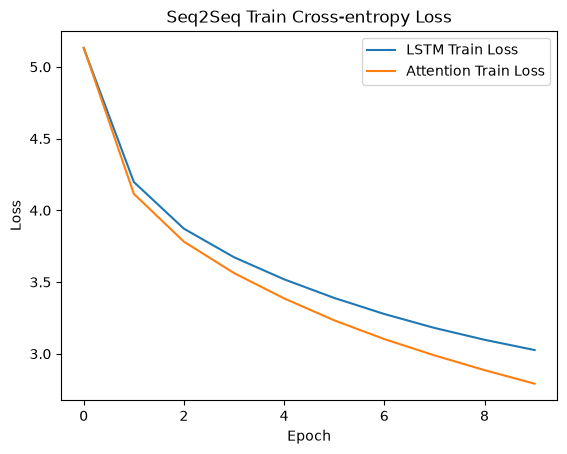

In [33]:
plt.plot(lstm_train_loss, label=f"LSTM Train Loss")
plt.plot(att_train_loss, label=f"Attention Train Loss")
plt.title("Seq2Seq Train Cross-entropy Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### 5-4. BLEU 점수로 평가하기
- 기계 번역이나 텍스트 생성 모델의 성능을 평가하는 대표적인 자동 평가지표
- AI가 만든 문장이 정답 문장과 얼마나 가까운지를 0~100 사이 점수로 표시 -> 100에 가까울수록 정답과 가까움!

In [ ]:
def evaluate_translate(
    model,
    dataloader,
    vocab,
    references,
    device,
    max_new_tokens: int
):
    model.eval()
    preds = []

    with torch.no_grad():
        for source, _, _, valid_mask in dataloader:
            source = source.to(device)
            valid_mask = valid_mask.to(device)

            token_ids = \
                model.greedy_decode(source, valid_mask, max_new_tokens=max_new_tokens)
            if isinstance(token_ids, tuple):
                token_ids = token_ids[0]

            token_ids = token_ids.to('cpu')
            for pred_ids in token_ids:
                pred = decode_text(pred_ids, vocab)
                preds.append(pred)

    preds = [
        re.sub(r"\s+([.,!?])", r"\1", text)
        for text in preds
    ]
    assert len(preds) == len(references)

    bleu = BLEU(lowercase=True)
    score = bleu.corpus_score(preds, [references])
    return score, preds

In [75]:
valid_loader = DataLoader(
    dataset=dataset['validation'],
    batch_size=64,
    shuffle=False,
    collate_fn=multi30k_collate_fn
)
test_loader = DataLoader(
    dataset=dataset['test'],
    batch_size=64,
    shuffle=False,
    collate_fn=multi30k_collate_fn
)

max_new_tokens = max(
    len(encode_text(text, en_token_to_id)) + 1
    for text in dataset['validation']['en']
)

lstm_valid_score, lstm_valid_preds = evaluate_translate(
    lstm_model, valid_loader, en_vocab, list(dataset["validation"]["en"]), device, max_new_tokens
)
att_valid_score, att_valid_preds = evaluate_translate(
    att_model, valid_loader, en_vocab, list(dataset["validation"]["en"]), device, max_new_tokens
)

print(f"LSTM Model BLEU Score: {lstm_valid_score.score}")
print(f"Attention Model BLEU Score: {att_valid_score.score}")

LSTM Model BLEU Score: 7.508476937108542
Attention Model BLEU Score: 12.975712175828274


In [76]:
# 독일어 source 문장을 tokenization 한 후의 토큰 개수에 따른 결과
bucket_indices = {
    "1-10": [],
    "11-20": [],
    "21+": [],
}

for sample_idx, source_text in enumerate(dataset["validation"]["de"]):
    source_ids = encode_text(source_text, de_token_to_id)
    source_length = len(source_ids)

    if source_length <= 10:
        bucket_name = "1-10"
    elif source_length <= 20:
        bucket_name = "11-20"
    else:
        bucket_name = "21+"

    bucket_indices[bucket_name].append(sample_idx)

for bucket_name, indices in bucket_indices.items():
      print(f"Bucket Name: {bucket_name}, Bucket Len: {len(indices)}")

assert sum(
    len(indices)
    for indices in bucket_indices.values()
) == len(dataset["validation"])

Bucket Name: 1-10, Bucket Len: 342
Bucket Name: 11-20, Bucket Len: 619
Bucket Name: 21+, Bucket Len: 53


In [77]:
# 각 토큰 길이 별 BLEU 점수 구하기
bucket_results = {}
for bucket_name, indices in bucket_indices.items():
    bucket_dataset = dataset["validation"].select(indices)

    bucket_loader = DataLoader(
        bucket_dataset,
        batch_size=64,
        shuffle=False,
        collate_fn=multi30k_collate_fn
    )

    lstm_score, _ = evaluate_translate(
        lstm_model, bucket_loader, en_vocab, list(bucket_dataset["en"]), device, max_new_tokens
    )
    attention_score, _ = evaluate_translate(
        att_model, bucket_loader, en_vocab, list(bucket_dataset["en"]), device, max_new_tokens
    )

    bucket_results[bucket_name] = {
        "count": len(indices),
        "lstm": lstm_score.score,
        "attention": attention_score.score,
    }

for bucket_name, result in bucket_results.items():
    print(bucket_name, result)

1-10 {'count': 342, 'lstm': 7.247634915495647, 'attention': 14.414215608404078}
11-20 {'count': 619, 'lstm': 7.831969275859139, 'attention': 13.040823118349918}
21+ {'count': 53, 'lstm': 5.246808267093741, 'attention': 9.241933220147365}


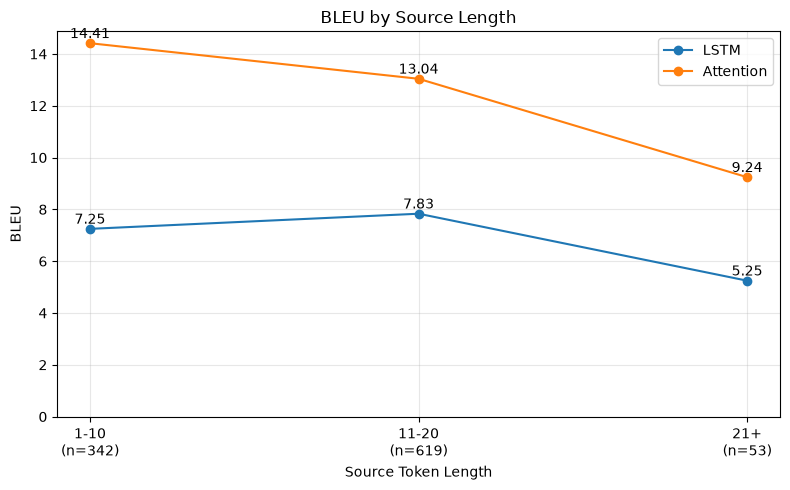

In [78]:
bucket_names = list(bucket_results.keys())
x = range(len(bucket_names))

x_labels = [
    f"{name}\n(n={bucket_results[name]['count']})"
    for name in bucket_names
]

lstm_scores = [
    bucket_results[name]['lstm']
    for name in bucket_names
]
attention_scores = [
    bucket_results[name]['attention']
    for name in bucket_names
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    x,
    lstm_scores,
    marker="o",
    label="LSTM",
)

ax.plot(
    x,
    attention_scores,
    marker="o",
    label="Attention",
)

ax.set_xticks(x, labels=x_labels)
ax.set_xlabel("Source Token Length")
ax.set_ylabel("BLEU")
ax.set_title("BLEU by Source Length")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend()

for index, score in enumerate(lstm_scores):
    ax.text(index, score + 0.2, f"{score:.2f}", ha="center")

for index, score in enumerate(attention_scores):
    ax.text(index, score + 0.2, f"{score:.2f}", ha="center")

plt.tight_layout()
plt.show()

In [79]:
sample_idx = bucket_indices["21+"][25]

source_text = dataset["validation"][sample_idx]["de"]
raw_target_text = dataset["validation"][sample_idx]["en"]
lstm_prediction = lstm_valid_preds[sample_idx]
attention_prediction = att_valid_preds[sample_idx]

print("Source:")
print(source_text)

print("\nRaw Target:")
print(raw_target_text)

print("\nLSTM:")
print(lstm_prediction)

print("\nAttention:")
print(attention_prediction)

Source:
Eine ältere Frau mit einer blauen Mütze sitzt auf dem Gehweg und hackt etwas Gelbes auf einem Brett neben sich.

Raw Target:
An elderly woman wearing a blue hat is sitting on the sidewalk chopping something yellow on a board beside her.

LSTM:
a woman in a blue shirt is holding a <unk> and <unk> on the street.

Attention:
an older woman with a blue shirt is sitting on the sidewalk while sitting on a bench.
